# ANN for regression_Model_3
### Dataset name is "California Housing Prices"
### (https://www.kaggle.com/datasets/camnugent/california-housing-prices)
### The dataset is 20.6K rows, can be considered as a medium dataset. It contains 7 numeric columns, 2 columns with coordinates, and one column with categorical value - text values. The target variable is "median house value". 
#### In this model I will calculate distance to nearest big cities and will check if that will improve prediction and metrics of the model.

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics


import tensorflow as tf
import keras
from keras import layers

## Loading the dataset

In [3]:
# load data 
df = pd.read_csv("housing.csv")

In [4]:
# According to CharGPT is it enouth for small ANN model, good enough to learn basic patterns. 
len(df)

20640

In [5]:
# the dataset has 10 clolumns, and one "ocean_proximity" is categorical. I will need to encode it properly (one-hot encoding)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<Axes: >

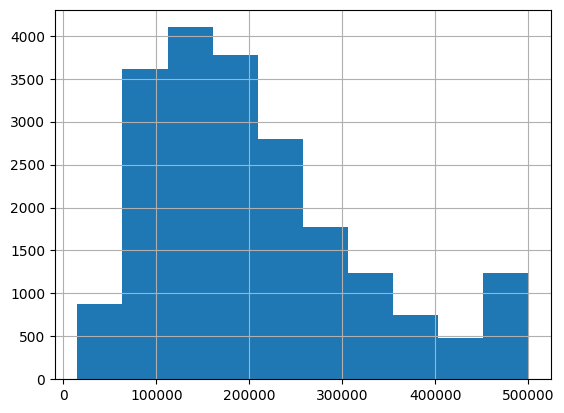

In [6]:
# this plot shows that the target variable is right-skewed, there's a smaller group of homes with very high price, this tail indicates high-value homes
# let's remove the outliers for better model performance
df['median_house_value'].hist()

In [7]:
# we will use quantiles to remove the top % in order to get closer to normal distribution
df = df.query("median_house_value < median_house_value.quantile(0.93)")

<Axes: >

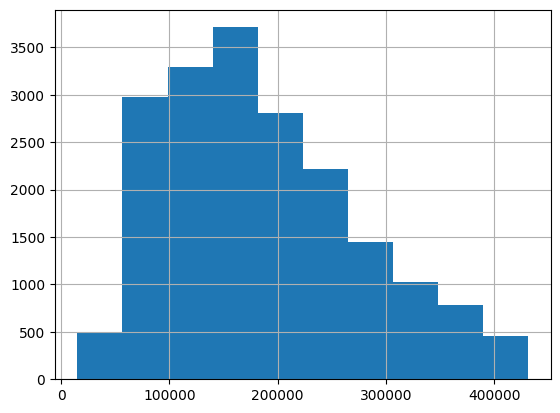

In [8]:
# now it looks better:
df['median_house_value'].hist()

In [9]:
# check if we have any missing values
df.isna().sum()

# we have missing values. I cannot fill them with median value as depends on how big a house is. I will drop them for now, not later will check how it will affect the results.

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        196
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [10]:
# dropping rows with missing values
df = df.dropna()

In [11]:
df.isna().sum()

# now we don't have any missing values

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [12]:
# check duplicates
int(df.duplicated().sum())

# no duplicates

0

## Handling the categorical variables

In [13]:
# "ocean_proximity" is nominal categorical variable, I will use one-hot encoding to convert it to numerical
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [14]:
# by using encoder we will add 5 new columns, but will remove one -  and the original one.
from sklearn.preprocessing import OneHotEncoder
variables = ['ocean_proximity']

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [15]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,0,0,0,1,0


In [16]:
# dropping the last variable:
df = df.drop("ocean_proximity_NEAR OCEAN", axis=1)

In [17]:
# let's check:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,0,0,0,1


### Let's check the correlation between the features against each other and check distribution of support variables:

<Axes: >

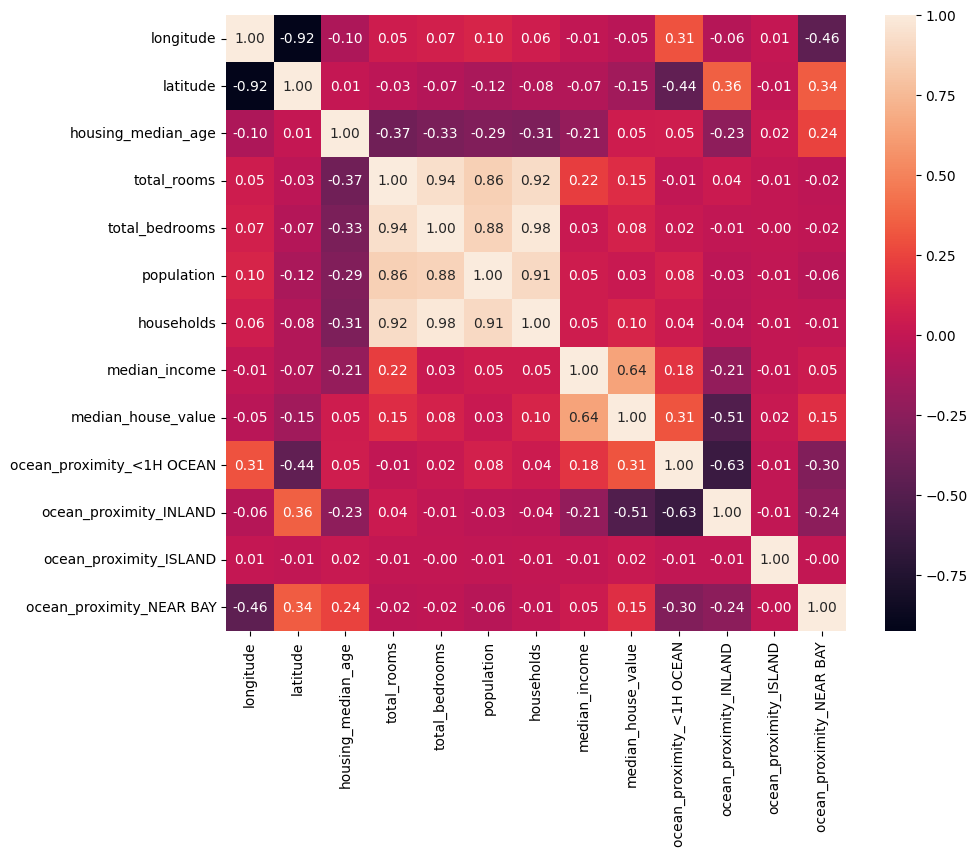

In [18]:
# it was difficult to see numbers, so we will increase the figure size:
plt.figure(figsize=(10, 8))

# on this correlation matrix we can see the most important supported variables:
# median_income. 
correlations = df.corr(numeric_only=True)
sns.heatmap(correlations, annot=True, fmt='.2f')

In [19]:
# based on my analysis of this df and correlation matrix, there is redundancy between total_bedrooms and total_rooms,
# population and households, so I will drop total_bedrooms and households as they are less correlated with the target variable.

df = df.drop(['total_bedrooms', 'households'], axis=1) 

### Support variables based on correlations are: "median_income" and "ocean_proximity_<1H OCEAN" but the last has poor connection, just 0.26.

<Axes: xlabel='median_income', ylabel='Count'>

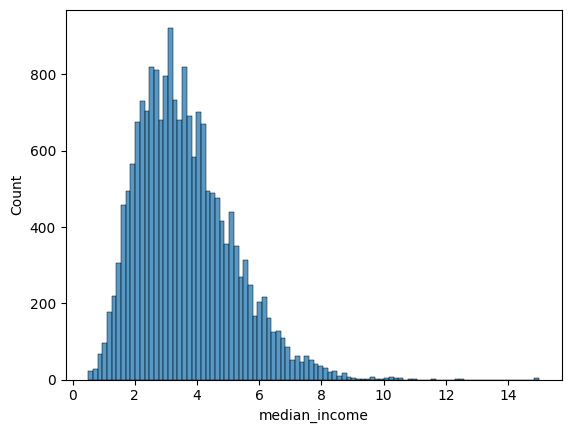

In [20]:
# let's check the distribution of median_income
sns.histplot(df['median_income'])

# this time I will remove the outliers above 99%

In [21]:
df = df.query("median_income < median_income.quantile(0.99)")

<Axes: xlabel='median_income', ylabel='Count'>

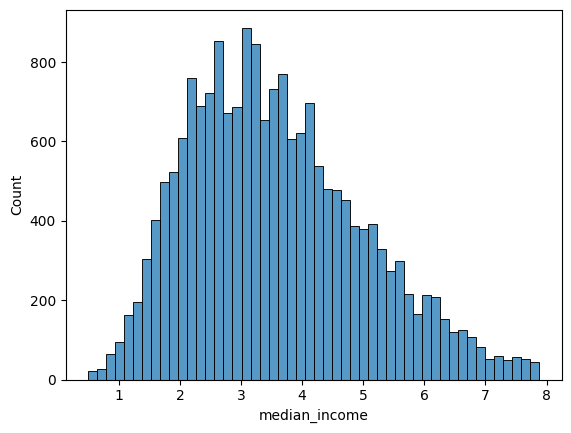

In [22]:
# looks also better:
sns.histplot(df['median_income'])

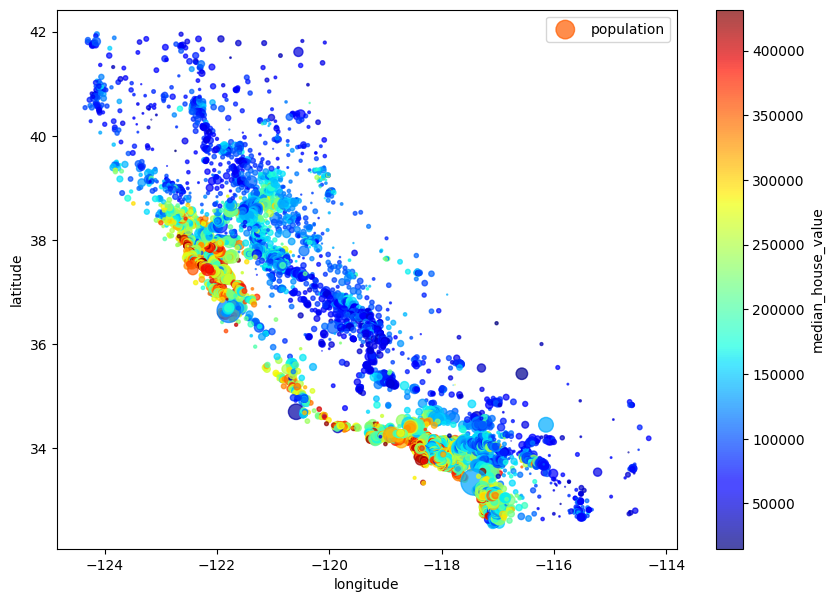

In [23]:
# let's check coordinates against the target variable:

df.plot(kind="scatter", x="longitude",y="latitude", c="median_house_value", cmap="jet", colorbar=True, legend=True, sharex=False, figsize=(10,7), s=df['population']/100, label="population", alpha=0.7)
plt.show()

# We can see that houses near ocean are the most expensive but there are some outliers,
# and we can spot two big cities Los Angeles and San Francisco, where expensive houses concentrate.  


# Ref:https://medium.com/@basumatary18/implementing-linear-regression-on-california-housing-dataset-378e14e421b7#id_token=eyJhbGciOiJSUzI1NiIsImtpZCI6ImZhMDcyZjc1Nzg0NjQyNjE1MDg3YzcxODJjMTAxMzQxZTE4ZjdhM2EiLCJ0eXAiOiJKV1QifQ.eyJpc3MiOiJodHRwczovL2FjY291bnRzLmdvb2dsZS5jb20iLCJhenAiOiIyMTYyOTYwMzU4MzQtazFrNnFlMDYwczJ0cDJhMmphbTRsamRjbXMwMHN0dGcuYXBwcy5nb29nbGV1c2VyY29udGVudC5jb20iLCJhdWQiOiIyMTYyOTYwMzU4MzQtazFrNnFlMDYwczJ0cDJhMmphbTRsamRjbXMwMHN0dGcuYXBwcy5nb29nbGV1c2VyY29udGVudC5jb20iLCJzdWIiOiIxMTgyMDUxMTQ5NTgzODQ3NTcwODkiLCJlbWFpbCI6InN2ZXRsYW5hLmVtZGVuQGdtYWlsLmNvbSIsImVtYWlsX3ZlcmlmaWVkIjp0cnVlLCJuYmYiOjE3MzgzNTkyNTIsIm5hbWUiOiJTdmV0bGFuYSBFbWRlbi1CYXpoZW5vdmEiLCJwaWN0dXJlIjoiaHR0cHM6Ly9saDMuZ29vZ2xldXNlcmNvbnRlbnQuY29tL2EvQUNnOG9jTDVVOF81dTBRZGk1U0Z0QllIZFJwTFNRSDZkVkxTSTd2ejMxTUZQMTl4YjB0bnB3PXM5Ni1jIiwiZ2l2ZW5fbmFtZSI6IlN2ZXRsYW5hIiwiZmFtaWx5X25hbWUiOiJFbWRlbi1CYXpoZW5vdmEiLCJpYXQiOjE3MzgzNTk1NTIsImV4cCI6MTczODM2MzE1MiwianRpIjoiYzA1NDJiMDQ0YTMyODNjYThlN2Q2ZWZiZmRmYmI2NDExNDkxMDY4OSJ9.KE4D73fy_EXA0kP-cJkQAHDdDEp4eazJhRuFk3vIPBg7aC5x5Iia0IfOjjpmjfrVDKFrHOgujPRKVyRZ-cd4_LW2jffKnM4e5ZkzQLk1dpwpiHhZXS9t9h6VMuNRv-a6cEDu0wVR1oCj13sVVSua6sxu2cxvi74kV8dDftV6Ke_ve8XshVWRy2yEm4TBp42MphTQJQWJOlpAoy31CTqM6upLSUnYatnbIfbUVqwwJbyIP7TylHEqPKJHXFduj3Qdhi4edhUYc3pC5ahevpD2Im3kzAqOB3df6A6fRWB5c9Y9OAblTD3tiSYdmwBVDAZkK5fGIXrHD2jcUZ825_ZGQg 

In [24]:
# Let's check the length of df:
len(df)

# I decreased the number of rows by removing outliers from 20640 to 18809, but still have enough data to train the model.

18809

In [25]:
# here I will create a new feature "distance_to_nearest_city" based on longitude and latitude
# approximate coordinates of 2 biggerst cities:
sf_coords = (37.7749, -122.4194)  # San Francisco
la_coords = (34.0522, -118.2437)  # Los Angeles


In [26]:
# Use haversine formula (distance in km):

from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

In [27]:
# Create a column for the shortest distance:

df['distance_to_nearest_city'] = df.apply(
    lambda row: round(min(
        haversine(row['latitude'], row['longitude'], *sf_coords),
        haversine(row['latitude'], row['longitude'], *la_coords)
    ), 2),
    axis=1
)

# ChatGPT helped me to calculate the distance using haversine formula

In [28]:
# the new column appears
df.head()

,longitude,latitude,housing_median_age,total_rooms,population,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,distance_to_nearest_city
2,-122.24,37.85,52.0,1467.0,496.0,7.2574,352100.0,0,0,0,1,17.84
3,-122.25,37.85,52.0,1274.0,558.0,5.6431,341300.0,0,0,0,1,17.06
4,-122.25,37.85,52.0,1627.0,565.0,3.8462,342200.0,0,0,0,1,17.06
5,-122.25,37.85,52.0,919.0,413.0,4.0368,269700.0,0,0,0,1,17.06
6,-122.25,37.84,52.0,2535.0,1094.0,3.6591,299200.0,0,0,0,1,16.55


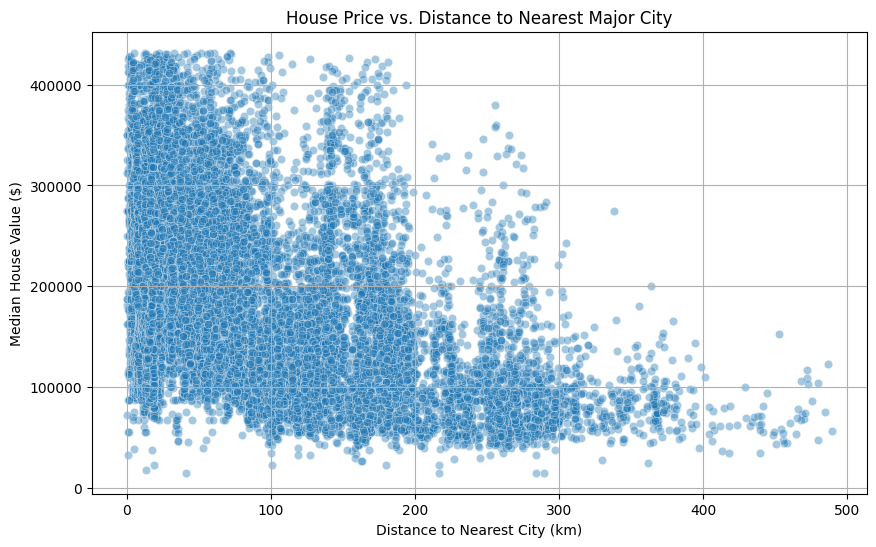

In [29]:
# let's chck if if closer houses are consistently more expensive. Does being closer to a city mean higher price?

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="distance_to_nearest_city", y="median_house_value", alpha=0.4)
plt.title("House Price vs. Distance to Nearest Major City")
plt.xlabel("Distance to Nearest City (km)")
plt.ylabel("Median House Value ($)")
plt.grid(True)
plt.show()

#### We can see clear downward trend. Homes that are closer to a major city (0–50 km) tend to have much higher prices, often above $300,000 and even $400,000. As distance increases beyond ~50–100 km, house prices drop significantly. Though there are a lot of outliers between 100 and 300 km of distance to the nearest city.  We can see price ceiling effect - flat top line around $500,000 as we removed outliers for the target variable. This adds noise. I will retrained the model to evaluate whether geographic proximity to major cities will improve prediction accuracy.

In [30]:
# UPDATE: I will drop here lon and lat and will see what are metrics will be:
df = df.drop(['longitude', 'latitude'], axis=1)

In [31]:
df.head()

,housing_median_age,total_rooms,population,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,distance_to_nearest_city
2,52.0,1467.0,496.0,7.2574,352100.0,0,0,0,1,17.84
3,52.0,1274.0,558.0,5.6431,341300.0,0,0,0,1,17.06
4,52.0,1627.0,565.0,3.8462,342200.0,0,0,0,1,17.06
5,52.0,919.0,413.0,4.0368,269700.0,0,0,0,1,17.06
6,52.0,2535.0,1094.0,3.6591,299200.0,0,0,0,1,16.55


## X/y -split

In [32]:
# perform X/y -split
# if you  have more than one independent variable, list them all here
# leave out the target variable! (dependent variable)

# this is a nice and common trick => everything EXCEPT target variable => support variable
X = df.drop("median_house_value", axis=1)

# have only the target variable here (dependent variable)
y = df["median_house_value"]

## Train/test/validation -split


In [33]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

## Create a neural network structure

In [34]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 

# Tip: have at least the same number of nodes as in the input shape

# since we have 13 support variables this time => 16 nodes in first layer

# output layer in regression is always 1 node without activation function
model = keras.Sequential(
    [
        layers.Dense(32, activation="relu", input_shape=(variable_amount,)),
        layers.Dropout(0.1),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

# select the optimizer and loss function
# you can try rmsprop also as optimizer, or stochastic gradient descent
model.compile(optimizer='adam', loss='mse')

# common tips on how to change neural network structure if your metrics are not good:

# make wider (or narrower) layers (for example, 64 or 128 nodes)
# make a longer or shorter network (add or remove layers)
# use Dropout -layers (e.g. layers.Dropout(0.1))

# remember: there's no process or mathematical formula
# in order to figure out the optimal neural network structure
# it's mostly all about trial and error => EXPERIMENTATION!

# remember to have enough "decision-space" for your data!
# it's highly unlikely a dataset with 20 different variables is going
# to work well with only 8 nodes in each layer etc.

# print out the summary of your model
model.summary()

c:\Storage\Studies\Lapland_AMK\5_semester\Deep_learning\.venv312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,489 (13.63 KB)

 Trainable params: 3,489 (13.63 KB)

 Non-trainable params: 0 (0.00 B)

## Train the neural network

In [35]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=800, validation_data=(X_val, y_val))

Epoch 1/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 25097140224.0000 - val_loss: 18155534336.0000
Epoch 2/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 18400876544.0000 - val_loss: 17612124160.0000
Epoch 3/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 17668532224.0000 - val_loss: 16813069312.0000
Epoch 4/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16660388864.0000 - val_loss: 15658630144.0000
Epoch 5/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15156699136.0000 - val_loss: 13836522496.0000
Epoch 6/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12885505024.0000 - val_loss: 10986368000.0000
Epoch 7/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9968735232.0000 - val_loss: 8187051008.0000
Epoch 8/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8359626240.0000 - val_loss: 7416159232.0000
Epoch 9/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7880092672.0000 - val_loss: 7199097344.0000
Epoch 10/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1

<Axes: >

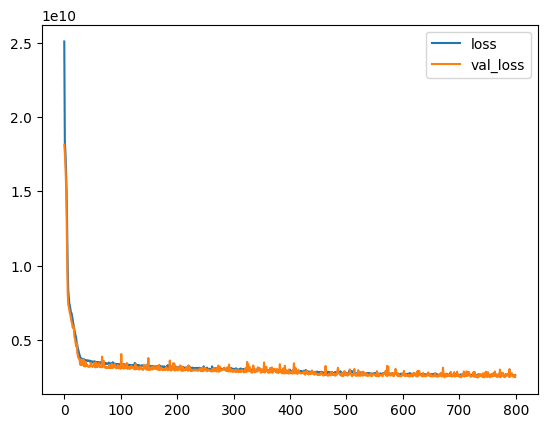

In [36]:
# let's use pandas for this (easy code)
# try to look if the model is actually training 
# => the error is going downwards
# if using validation data, you get two lines
# in this case, see if the lines follow a similar trend 
# (they don't always overlap with complex data, the trend is more important)
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [37]:
# compare the final model loss/evaluation values
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

Test data evaluation:
2459382528.0

Train data evaluation:
2383833344.0


### 

In [38]:
# get test predictions
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df

89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Test True Y,Model Predictions
0,263100.0,260155.234375
1,186900.0,213797.359375
2,130900.0,159127.250000
3,350000.0,123115.921875
4,191800.0,163023.109375
...,...,...
2817,102100.0,130458.304688
2818,177200.0,181651.437500
2819,266700.0,272137.500000
2820,381200.0,316106.125000


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

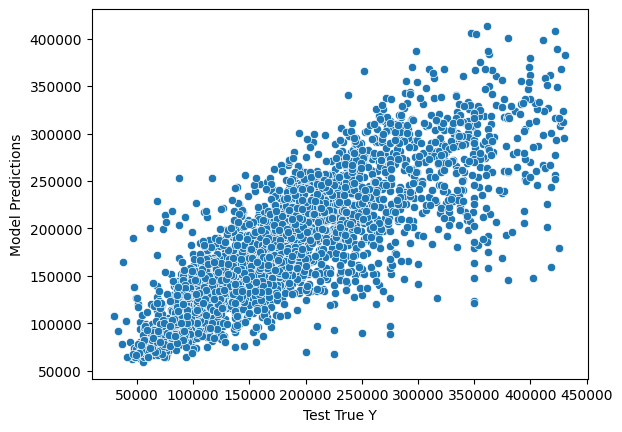

In [39]:
# these values follow a linear diagonal line = good predictions
# we basically compare the predicted values 
# to true test values and see the differences
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

In [40]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2), "$")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "$^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
36222.98 $

MSE
2459382307.8 $^2

RMSE:
49592.16 $

R-squared:
0.68

Explained variance score:
0.68


C:\Users\svetl\AppData\Local\Temp\ipykernel_21412\3124900743.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - test_predictions))


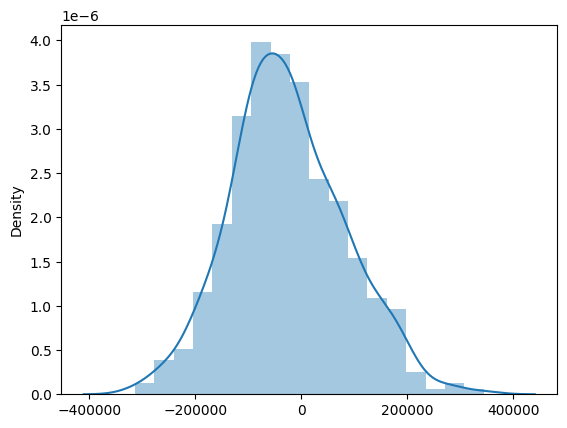

In [41]:
# if the prediction distribution are far from normal distribution
# then the model is not probably good enough
# distplot is deprecating in future pandas-version
# unfortunately, there's no exact alternative to do this plot at the moment
sns.distplot((y_test - test_predictions))
plt.show()
plt.close()

In [42]:
#### distribution looks quite normal, so the model is probably good enough

## Trying the model in practice with new imaginary house

In [43]:
# just to see what kind of values are usually in the dataset
# so we can test with the tester_row
df.head(3)

,housing_median_age,total_rooms,population,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,distance_to_nearest_city
2,52.0,1467.0,496.0,7.2574,352100.0,0,0,0,1,17.84
3,52.0,1274.0,558.0,5.6431,341300.0,0,0,0,1,17.06
4,52.0,1627.0,565.0,3.8462,342200.0,0,0,0,1,17.06


In [44]:
# example row for testing
print(X.columns.tolist())

['housing_median_age', 'total_rooms', 'population', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'distance_to_nearest_city']


In [45]:
# let's try with some new imaginary data

tester_row = {
    'housing_median_age': 41.0, 
    'total_rooms': 880.0, 
    'population': 322.0, 
     
    'median_income': 8.3252, 
    'ocean_proximity_<1H OCEAN': 0,
    'ocean_proximity_INLAND': 0,
    'ocean_proximity_ISLAND': 0,
    'ocean_proximity_NEAR BAY': 1,
    "distance_to_nearest_city" : 17.84,
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])

In [46]:
# get the prediction from the model and print out the result
result = model.predict(tester_row)[0]

print()
print(f"Estimated house price with this example:")
print(f"$ {round(float(result[0]), 2)}")
print("----------------")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

Estimated house price with this example:
$ 345378.69
----------------


### CONCLUSION: Scaling and Transformation Effectiveness (with help of ChatGRP) <br>
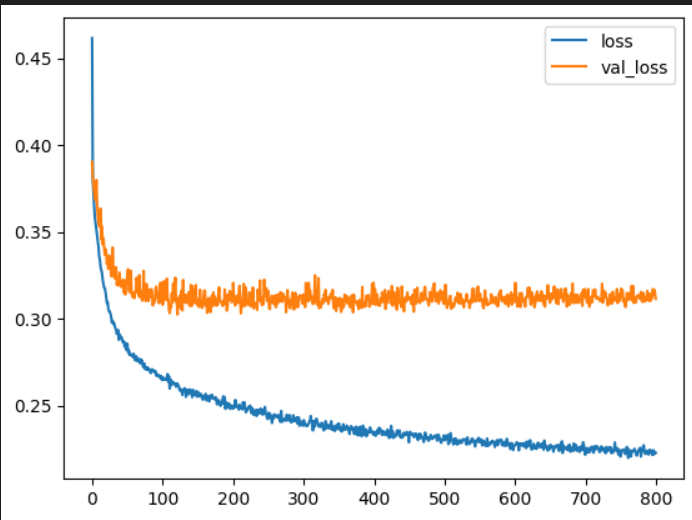 <br>
**What Was Applied:**
- X features: MinMaxScaler (0-1 normalization)
- y target: QuantileTransformer (normal distribution transformation)

**Issues Observed:**
1. **Validation loss plateaus**: Stops improving after ~100 epochs while training loss continues falling
2. **Growing overfitting gap**: Large divergence between training and validation loss by epoch 800
3. **Initial prediction error**: Model returned $242.25 (scaled space) - inverse-transform was missing
4. **Weak generalization**: Model memorizers training data but struggles on new data

**Assessment:**
Scaling/transformation alone did not prevent overfitting. It's a necessary preprocessing step but insufficient without proper regularization and early stopping. 


### SUMMARY (before dropping lon, lat):
#### the model undershoots the extimation, the price should be $ 452600.0 -> prediction is $ 382656.72 
#### First try: input layers 128 , R-squared: 0.7, Estimated house price with this example:$ 367107.09. Second try: input layers 64 , R-squared: 0.73 (the best one), Estimated house price with this example:$ 382656.72. The smaller model may have reduced overfitting or trained more efficiently as R-squared increased from 0.70 to 0.73 in the second try. The estimated price also got closer to the true price. This shows that adding distance_to_nearest_city improved model. The best model so fast is Model_3. For future improvements, I plan to explore how to handle or remove outliers that contribute to the price ceiling effect in the dataset. Specifically, many house prices are capped at $500,000, which may negatively effect the training process -> produse noise. By removing or transforming these outliers, I aim to reduce distortion in the target variable and potentially improve prediction accuracy, especially for higher-value homes

#### Summary of the Last Model Run
The model achieved an R² score of 0.68, indicating moderate predictive accuracy. Estimated house price is $ 345378.69 which is far from what should be. 
#### Conclusion Comparing All Three Models
1. Model 1: no feature engineering or scaling applied, r2 = 0.70. It performed well but lacked optimization.
2. Model 2: After outlier removal and feature selection, the R2 dropped to 0.61, showing that outlier removal negatively impacted performance.
3. Model 3: With feature engineering (distance-to-city) and no scaling, the R2 improved to 0.68. <br>
#### Model 1 remains the best in terms of R² (0.70), but Model 3 is not far r2 =0.68, where feature engineering were applied.